In [1]:
#########################
# Include Headers
#########################

using LinearAlgebra
using Arpack
using CairoMakie
using ColorSchemes


include("../header/.src/circuit/brickwall.jl")
include("../header/.src/plotmods/colorschemes_mods.jl")
include("../header/.src/random_matrices/random_matrices.jl")
include("../header/.src/measurements/projectors.jl")
include("../header/.src/info_lattice/info_lattice.jl")
include("../header/.src/info_lattice/draw_info_lattice.jl")


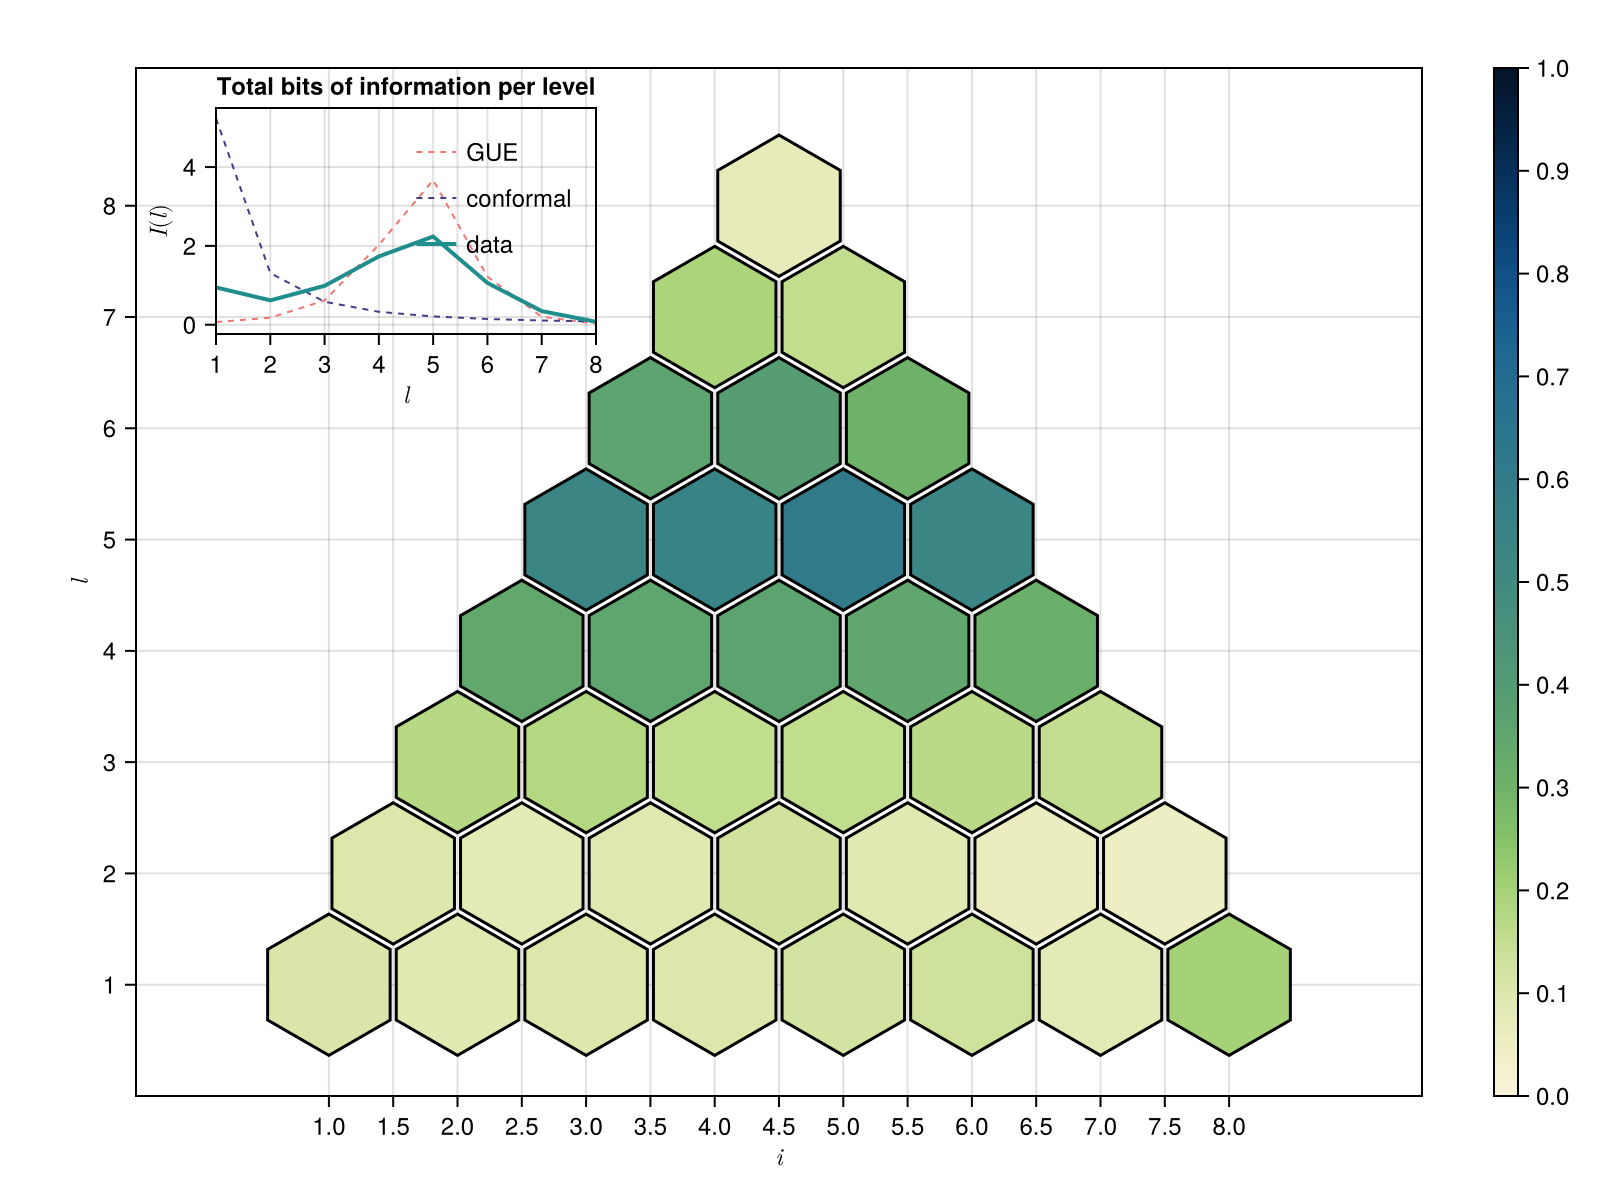

CairoMakie.Screen{IMAGE}


In [3]:
## DTC-MBL 

L=8
theta=0.0
epsilon=0.75

fig=draw_info_lattice(info_lattice_brickwall(L,theta, epsilon))
display(fig)

In [2]:

function phase_ordered_eigvecs(A)

  #########################################
    # Extracting local hilbert space dimension:
    #########################################

    localdim=length(eigvals(Z));
    
    #########################################
    # Extracting eigenvalues and eigenvectors of the input matrix A:
    #########################################

    EigA,Eigvec=eigen(A);
    N=angle.(EigA);
    
    #########################################
    # Defining a matrix to store the phase information of the eigenvectors:
    #########################################


    Ph=fill(0.0*im, length(EigA)+1,length(EigA));
    

    

    ########################################################
    # Storing the phase information of the eigenvectors in the matrix Ph:
    ########################################################

    Ph[1,:]=N;
    for i in 1:length(EigA);
        for j in 1:length(EigA)
            Ph[i+1,j]=Eigvec[i,j];
        end
    end
    
    ########################################################
    # Ordering the eigenstates from -pi to pi:
    ########################################################

    Phnew=copy(Ph[:,sortperm(real(Ph[1, :]))]); # Phase orders the eigenstates from -pi to pi
    EigvecNew=Eigvec;
    
    for i in 1:length(EigA);
        for j in 1:length(EigA)
            EigvecNew[i,j]=Phnew[i+1,j];
        end
    end
    
    return EigA,EigvecNew

end

phase_ordered_eigvecs (generic function with 1 method)

In [11]:
L=8
theta=0.0
epsilon=0.0
 
    U=brickwall(L,theta, epsilon)
    eigvalsA,eigvecsA=phase_ordered_eigvecs(U);



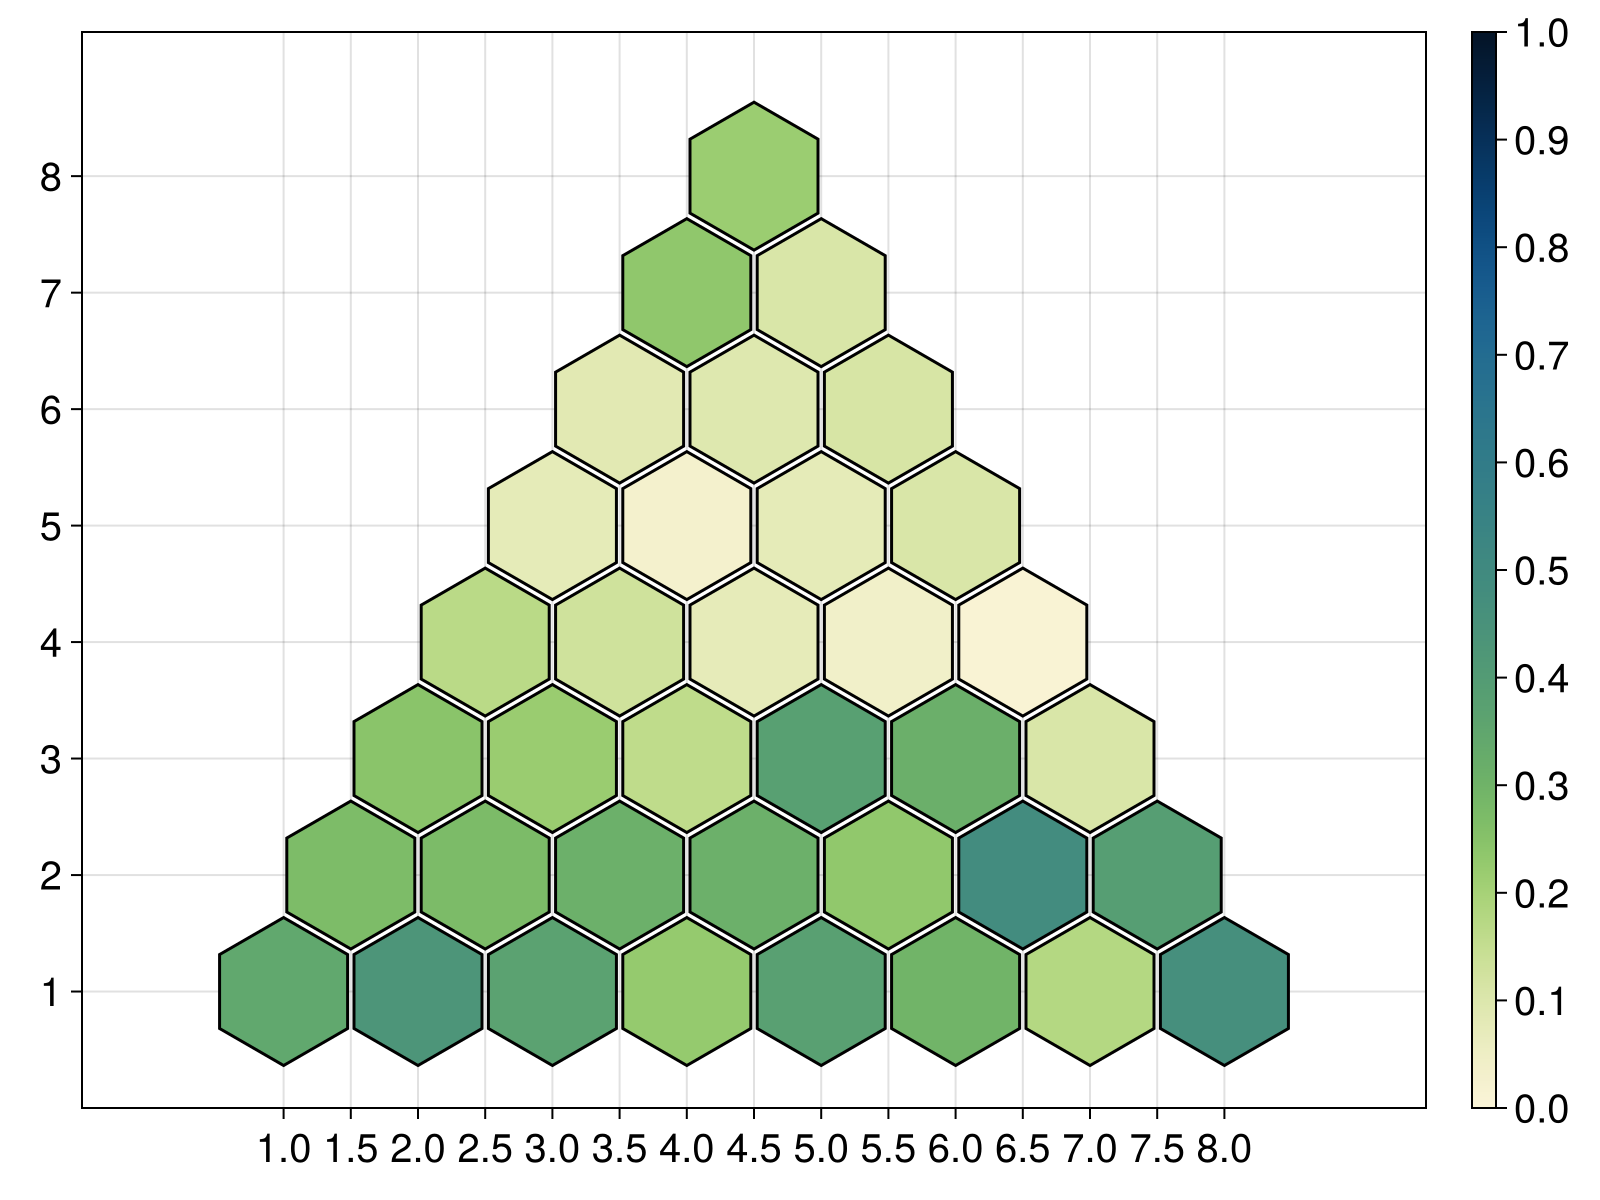

CairoMakie.Screen{IMAGE}


In [12]:

    Psi=(eigvecsA[1,:]+eigvecsA[129,:])./sqrt(2)
    infolattice=info_lattice(Psi, L)

    for i in 2:128
        Psi=(eigvecsA[i,:]+eigvecsA[128+i,:])./sqrt(2)
        infolattice+=info_lattice(Psi,L)
    end


    Psi=(eigvecsA[1,:]-eigvecsA[129,:])./sqrt(2)
    infolattice+=info_lattice(Psi, L)

    for i in 2:128
        Psi=(eigvecsA[i,:]-eigvecsA[128+i,:])./sqrt(2)
        infolattice+=info_lattice(Psi,L)
    end



    infolattice=infolattice./length(eigvalsA)

    fig=draw_info_lattice(infolattice)
display(fig)

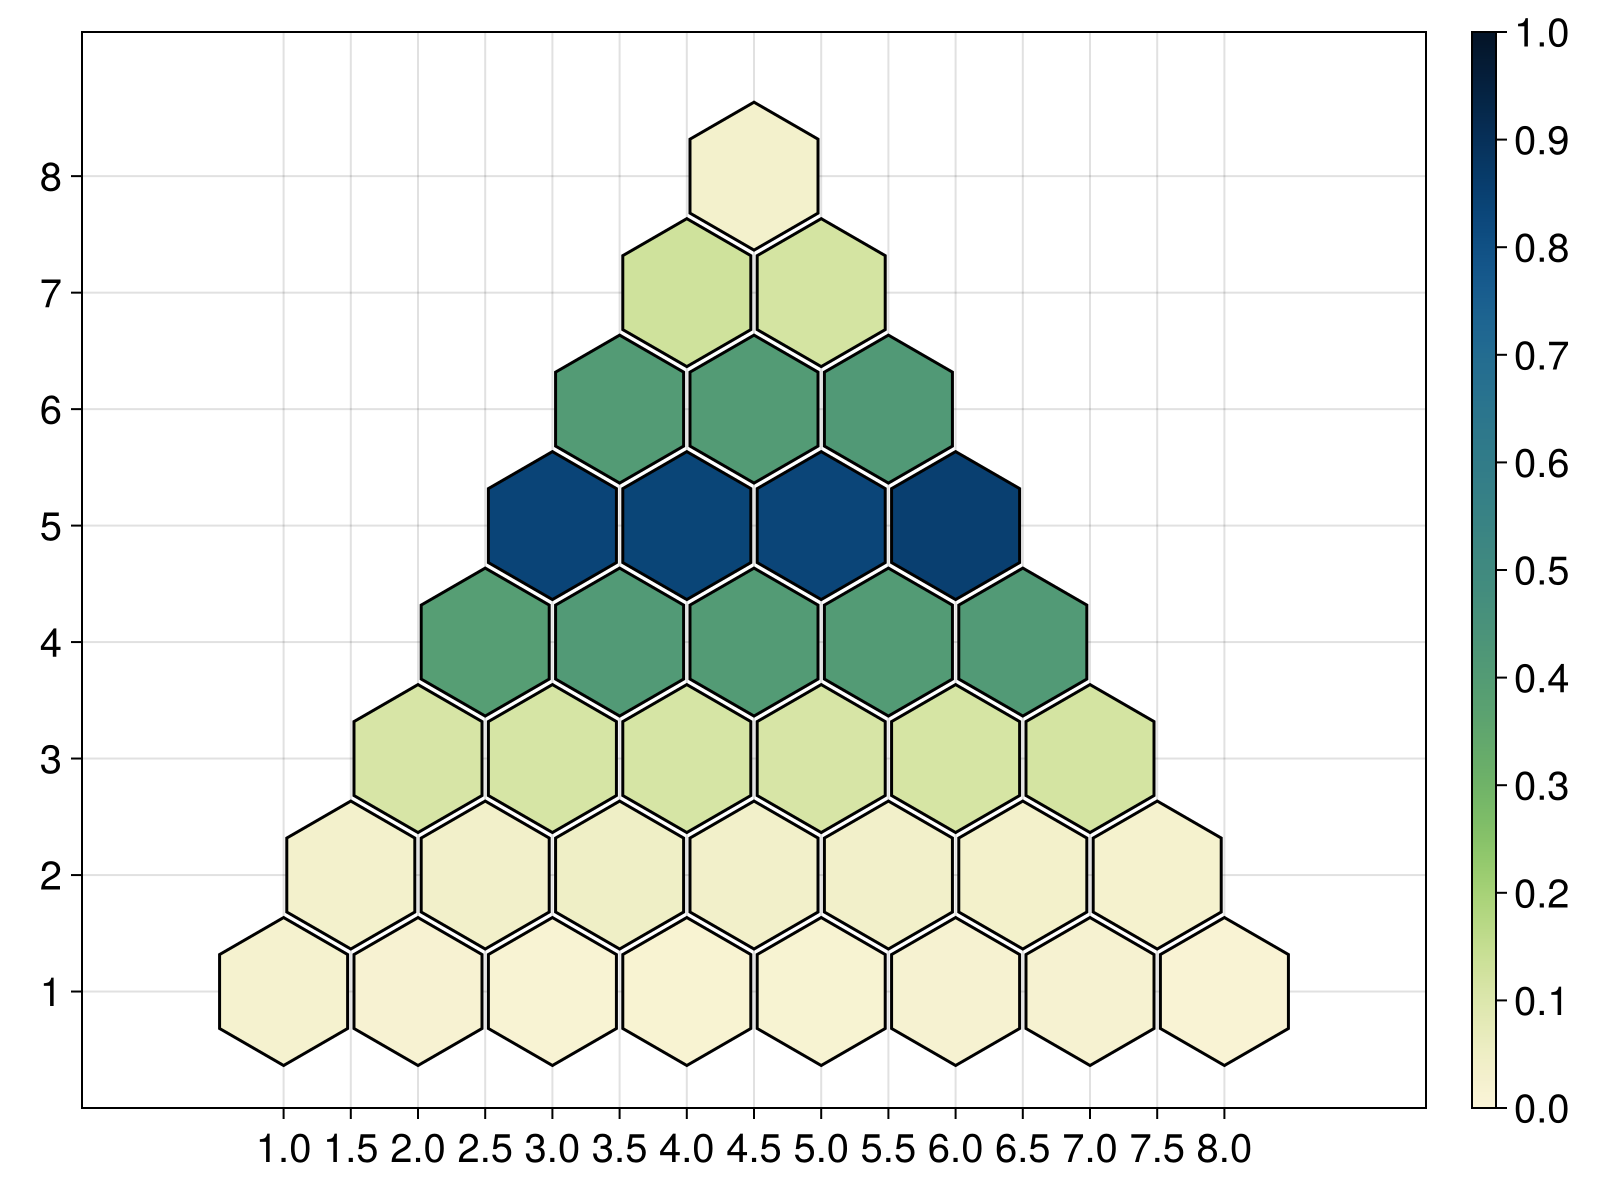

CairoMakie.Screen{IMAGE}


In [17]:
## Thermal

L=8
theta=0.0
epsilon=0.5

fig=draw_info_lattice(info_lattice_brickwall(L,theta, epsilon))
display(fig)


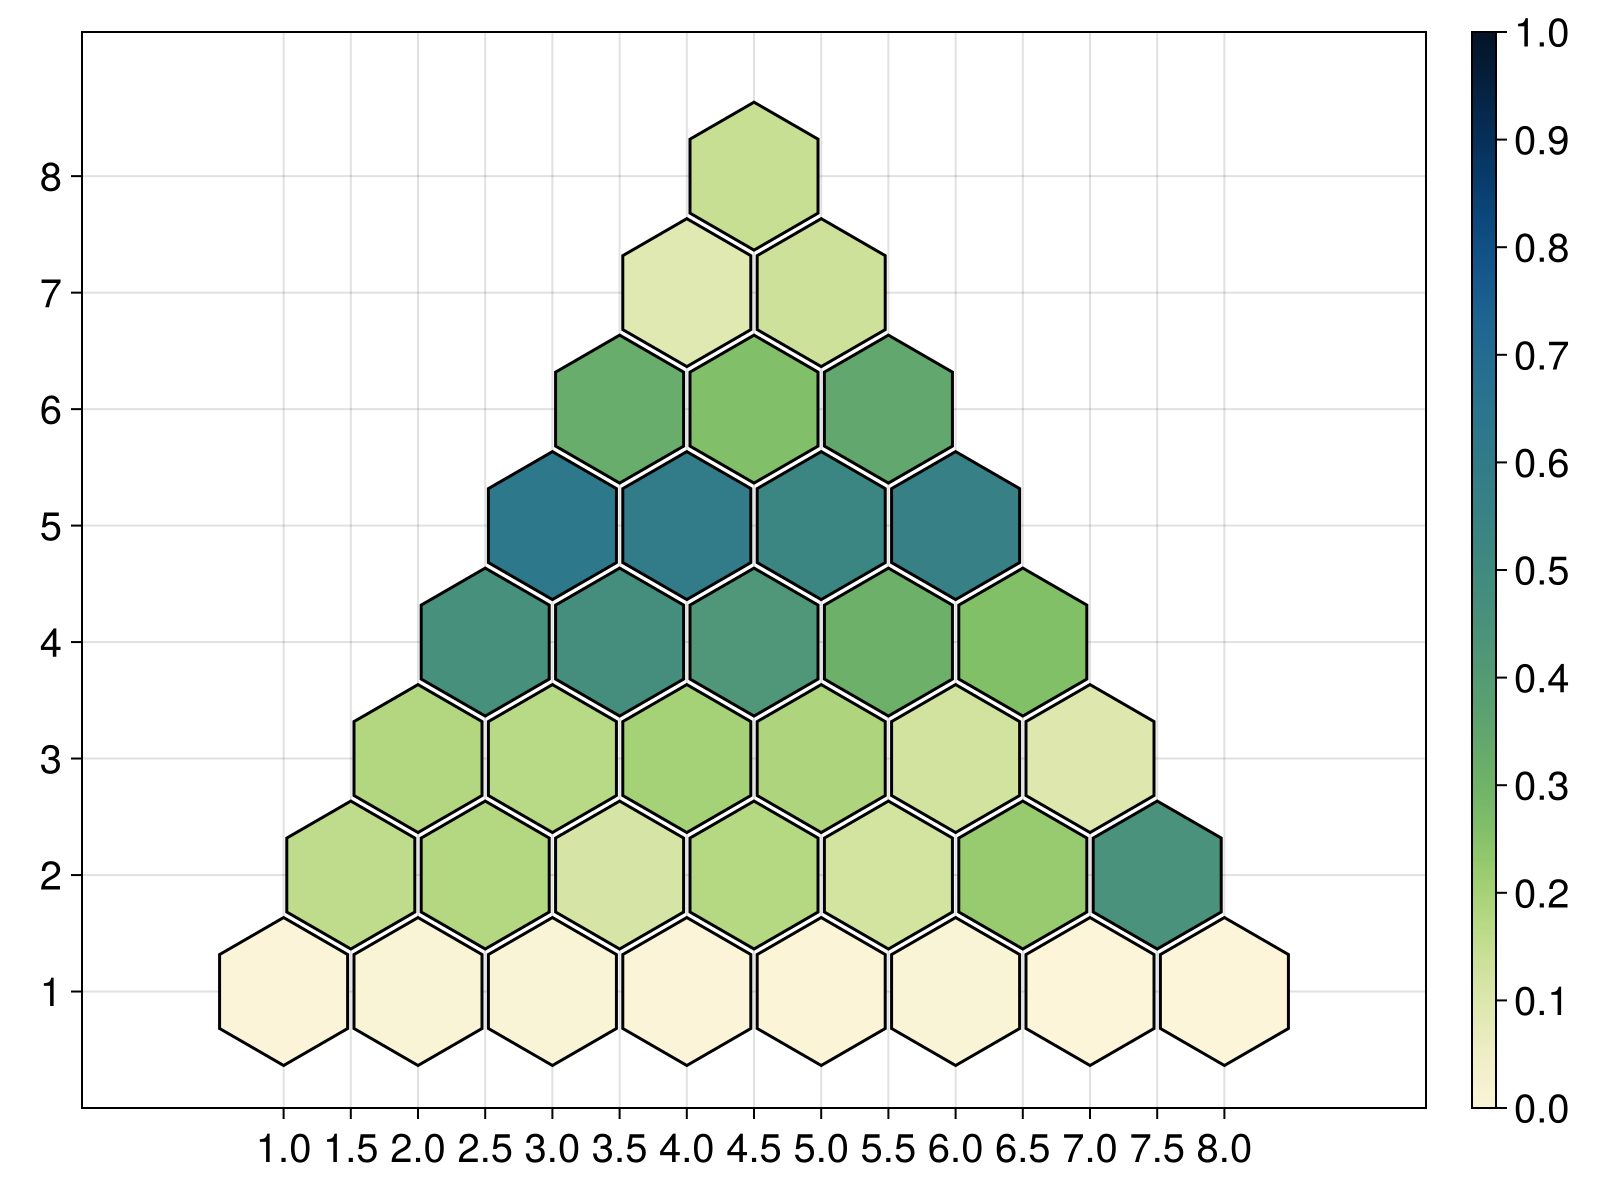

CairoMakie.Screen{IMAGE}


In [ ]:
## Critical-DTC 

L=8
theta=0.0
epsilon=0.1

fig=draw_info_lattice(info_lattice_brickwall(L,theta, epsilon))
display(fig)


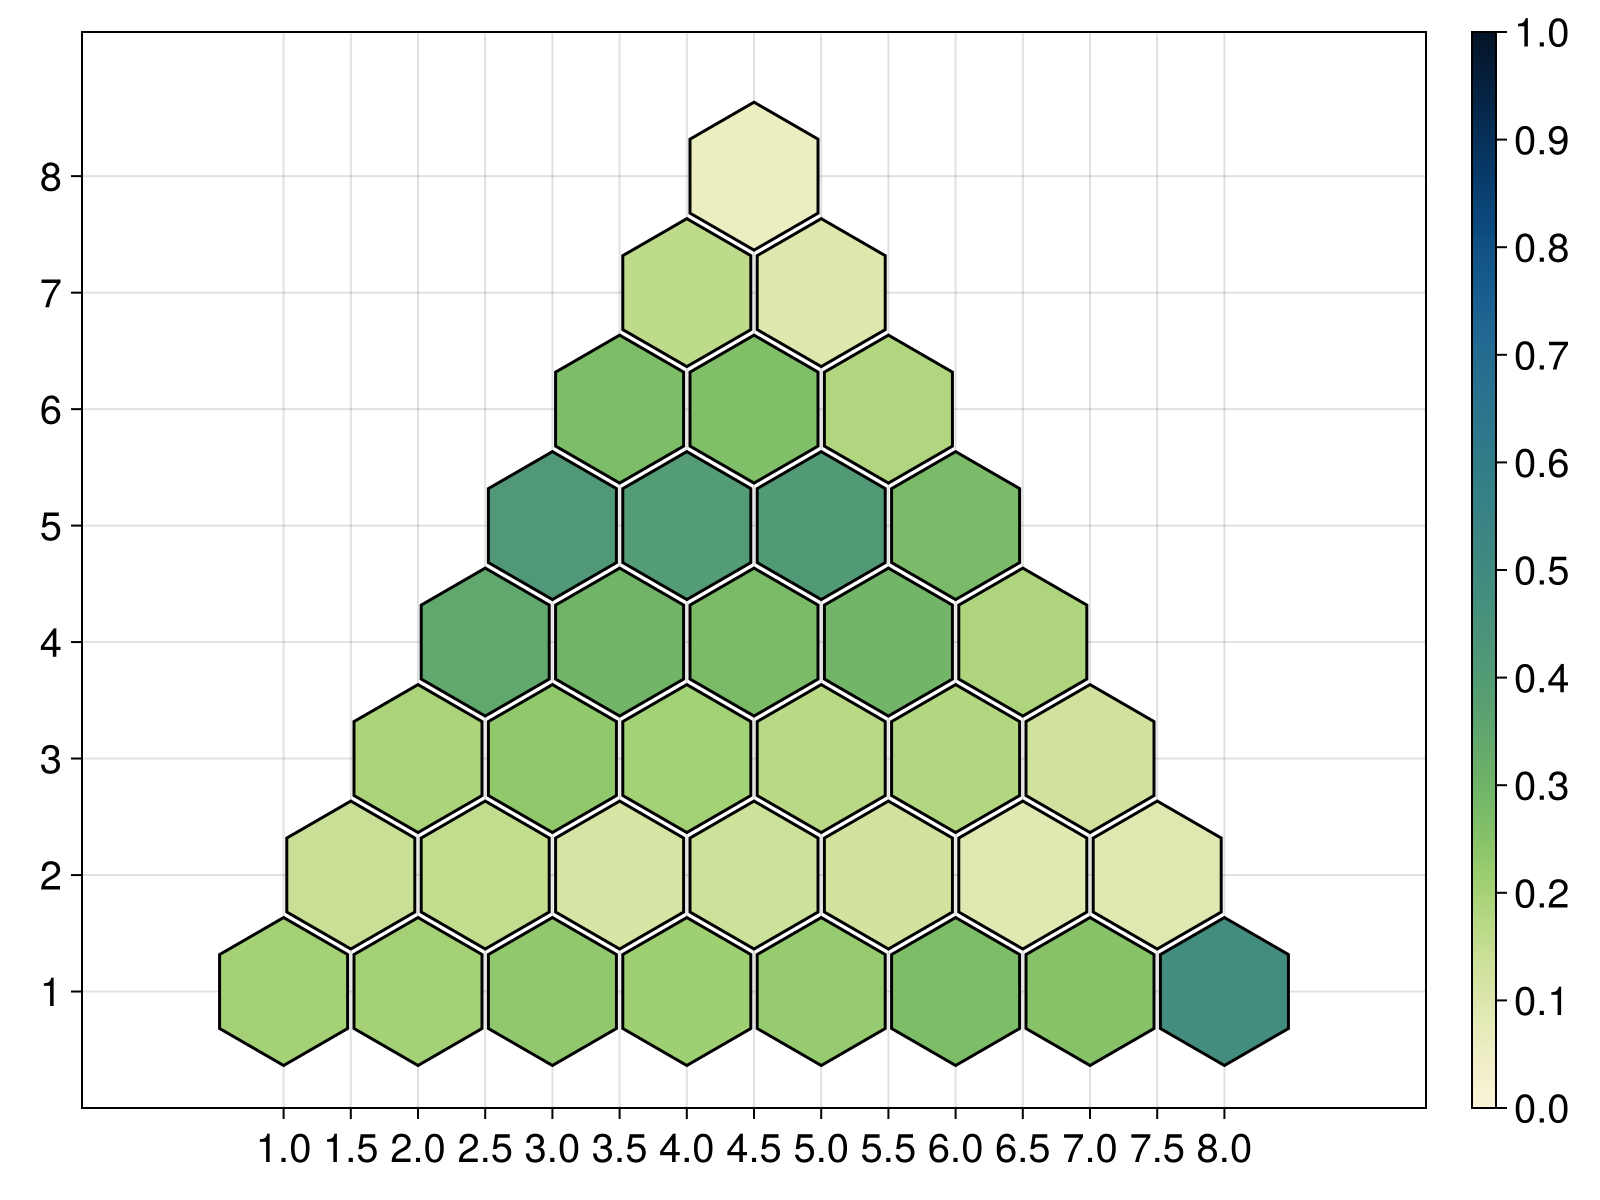

CairoMakie.Screen{IMAGE}


In [21]:
## Critical-PM-MBL 
L=8
theta=0.0
epsilon=0.85

fig=draw_info_lattice(info_lattice_brickwall(L,theta, epsilon))
display(fig)


In [ ]:
#Eigenstate of GUE

L=10
N=2^L
U=GUE(N)

infolattice=info_lattice(U)
    L=length(infolattice[1])

    info_lattice_sum=fill(0.0,L)
    for i in 1:L
        info_lattice_sum[i]=sum(infolattice[i])
    end



file = h5open("../header/.src/info_lattice/info_lattice_inset_data.hdf5", "cw")
file["GUE/info_lattice_sum/L$(L)"] = info_lattice_sum
close(file)

In [16]:
using HDF5
file = h5open("../header/.src/info_lattice/info_lattice_inset_data.hdf5", "r")
info_lattice_sum_GUE=file["GUE/info_lattice_sum/L$(L)"][:] 
close(file)
info_lattice_sum_GUE

8-element Vector{Float64}:
 0.06678035877061828
 0.17865922882745328
 0.6144919427391612
 2.0257297306339517
 3.6680239524286478
 1.2180010401551395
 0.2034867434057269
 0.024827003026591566

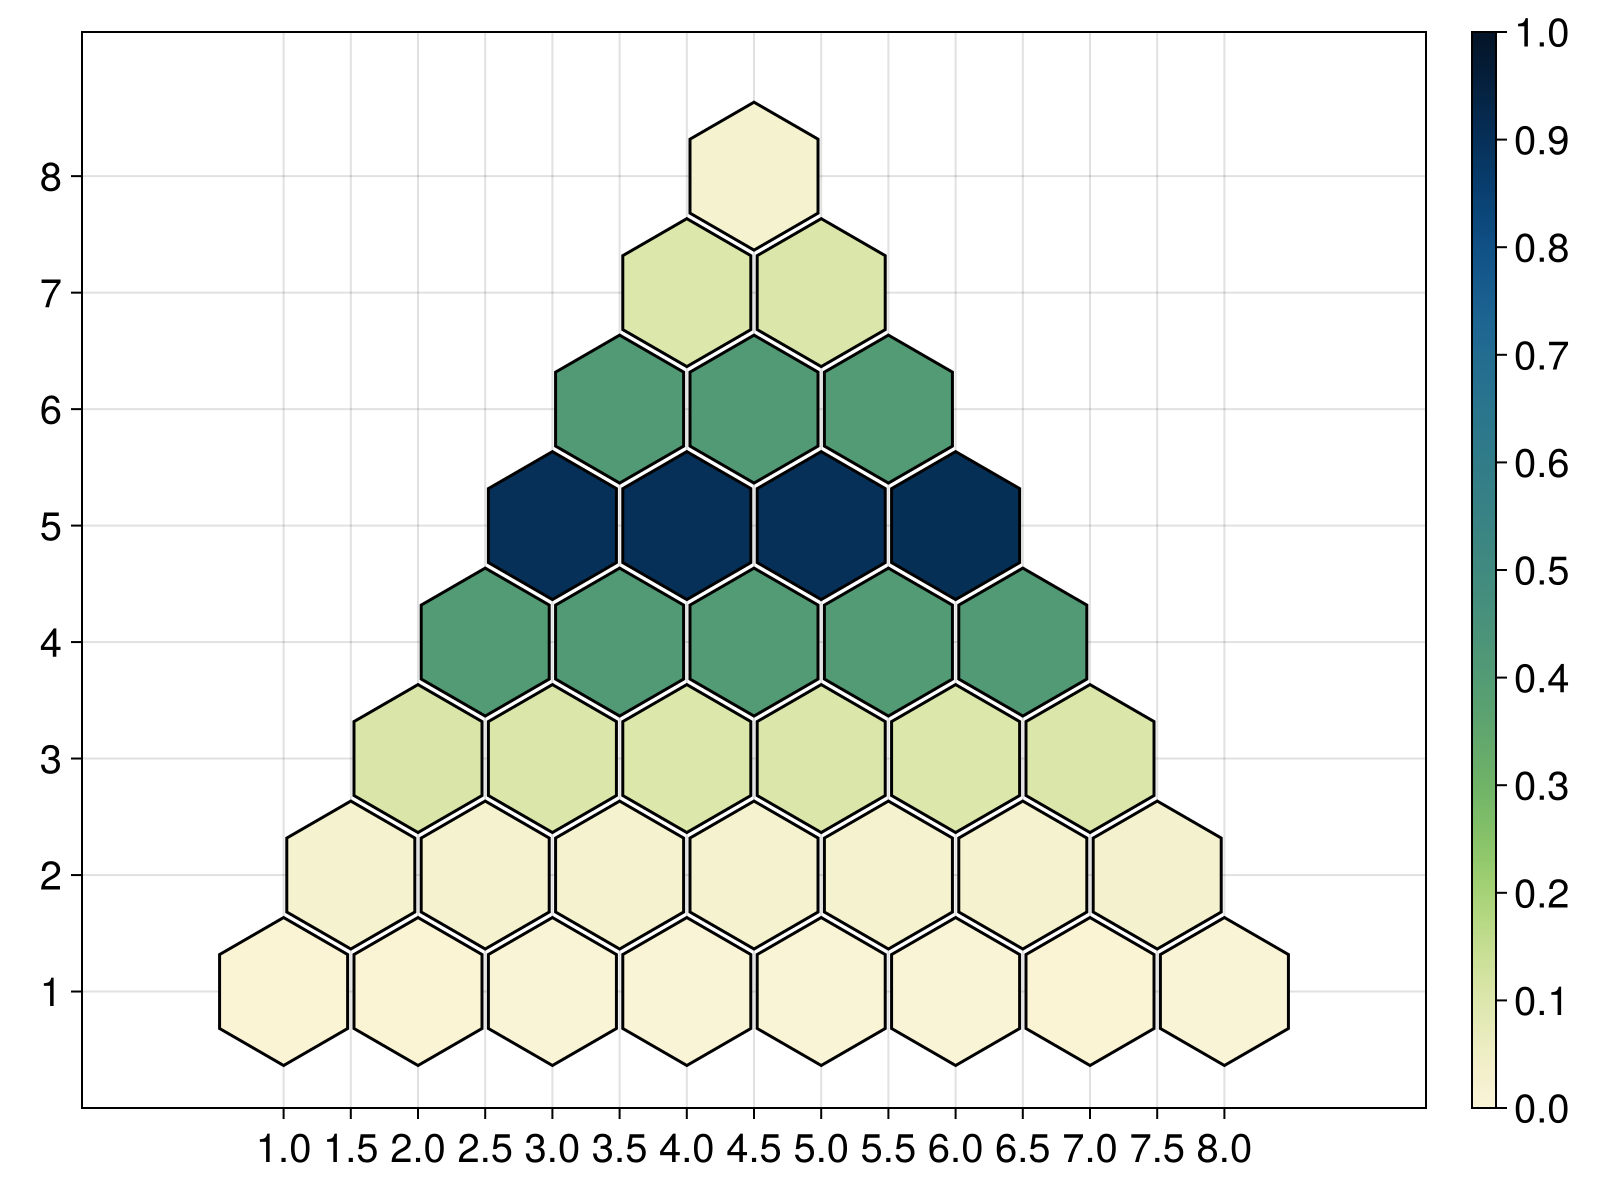

CairoMakie.Screen{IMAGE}


In [ ]:
## CKT

L=8
epsilon=0.5
theta=0.0

U=brickwall(L,theta, epsilon)
fig=draw_info_lattice(info_lattice(U))

display(fig)

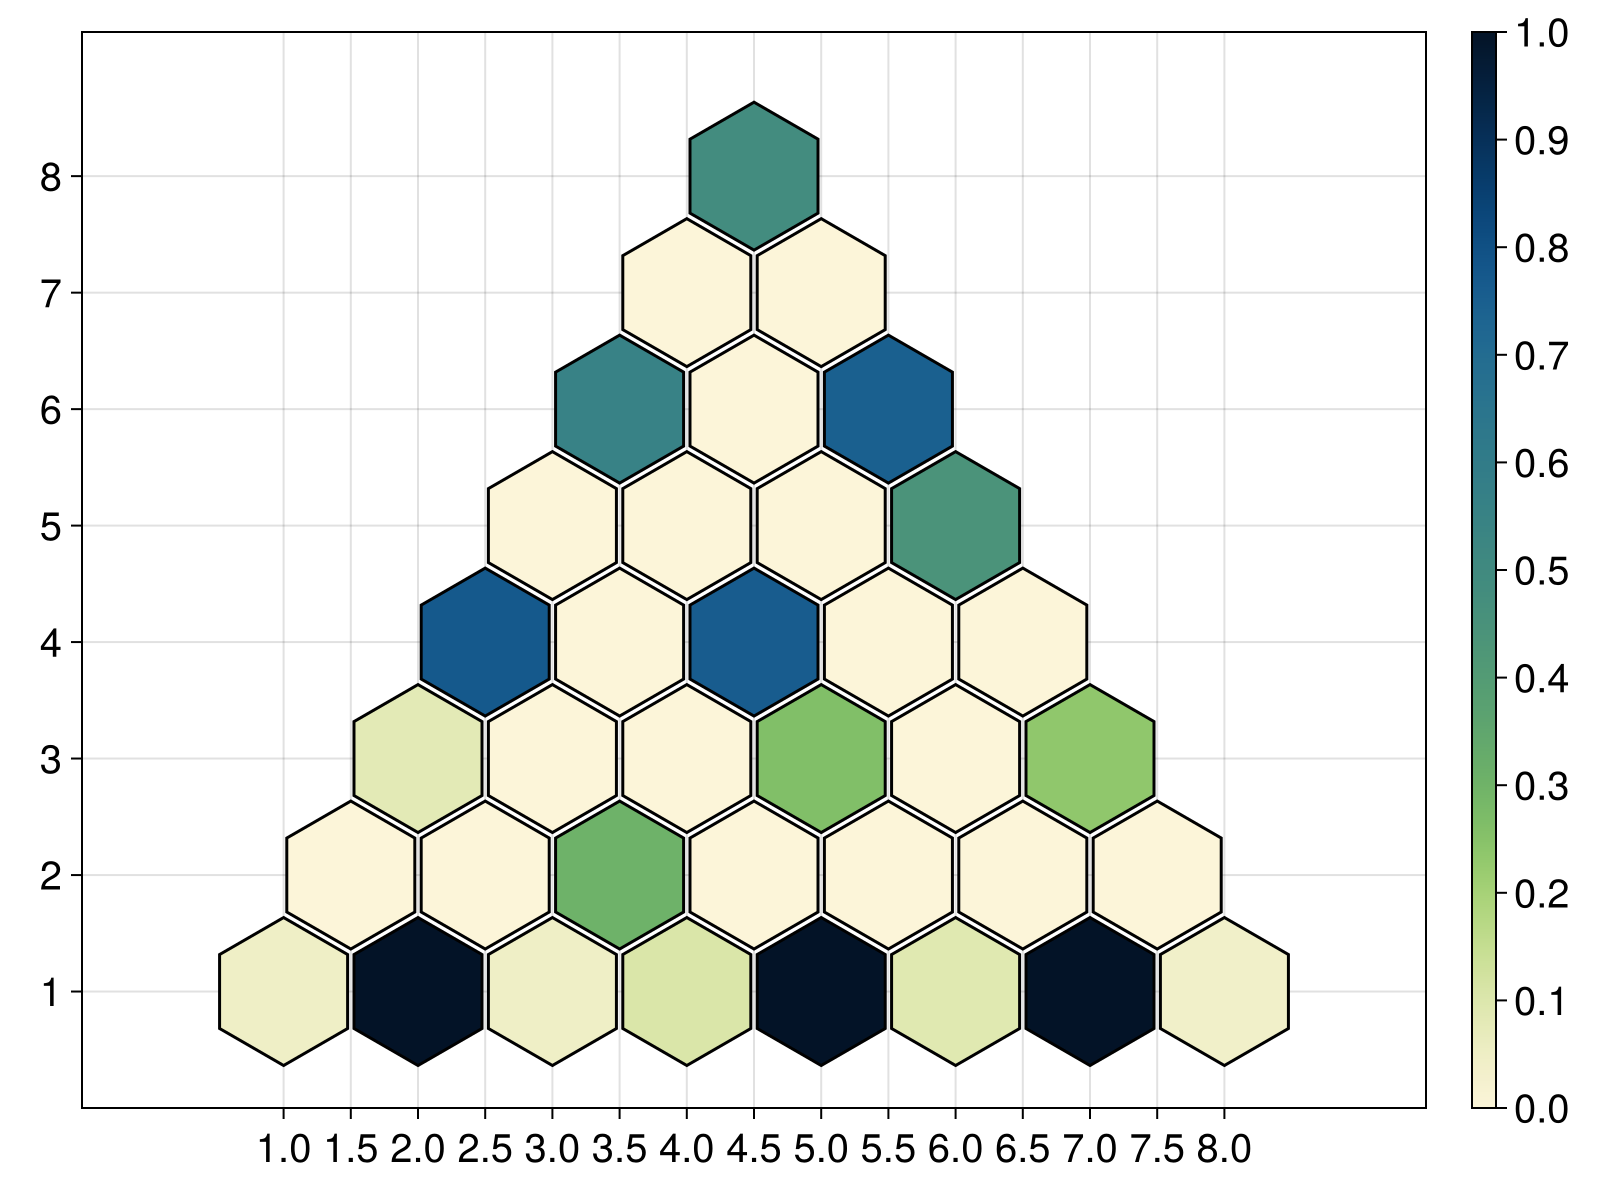

CairoMakie.Screen{IMAGE}


In [4]:
## CKT

L=8
epsilon=0.5
theta=0.0

U=brickwall(L,theta, epsilon)

eigvals,eigvecs=eigen(U);



info_lattice_t= Vector{Vector{Float64}}(undef, L)

 Psi=eigvecs[1,:]
 Psi=projectatt(Psi,[2 5 7])

info_lattice_t=info_lattice(Psi, L)




 fig=draw_info_lattice(info_lattice_t)
 display(fig)

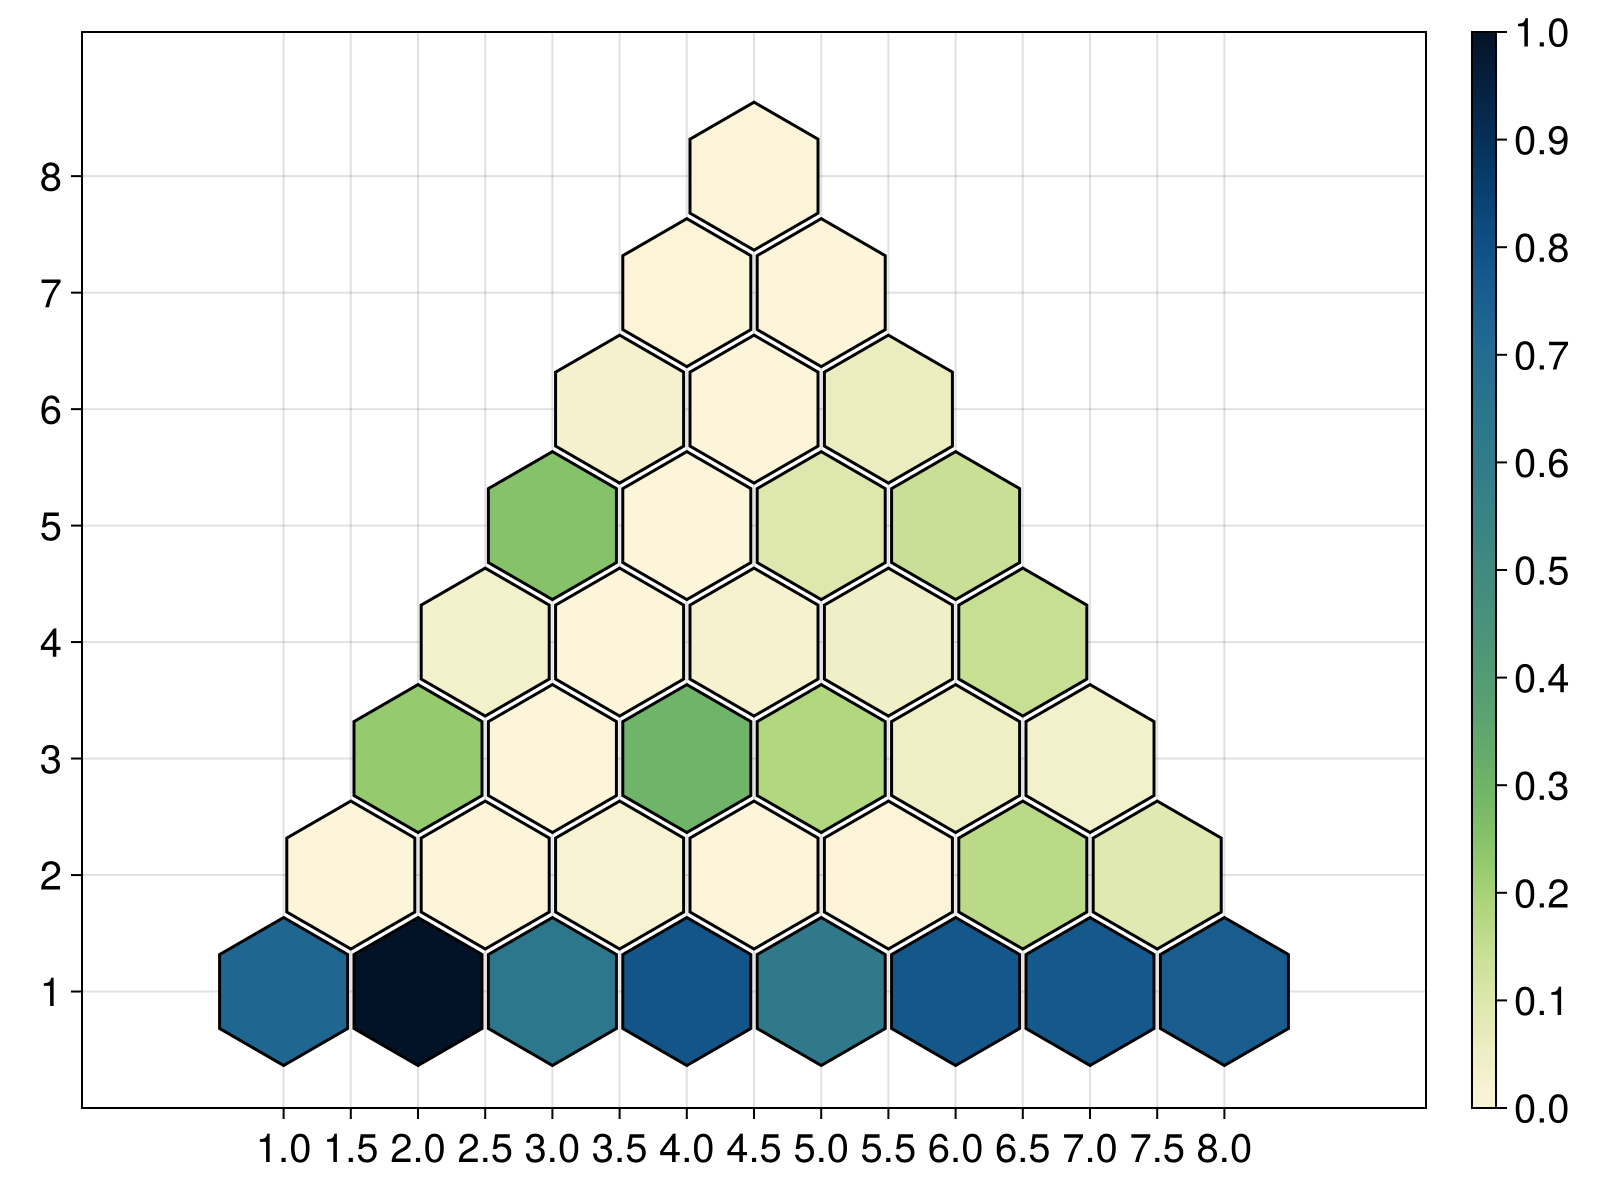

CairoMakie.Screen{IMAGE}


In [ ]:
## CKT

L=8
epsilon=0.85
theta=0.0

U=brickwall(L,theta, epsilon)

eigvals,eigvecs=eigen(U);



info_lattice_t= Vector{Vector{Float64}}(undef, L)

 Psi=eigvecs[1,:]
 Psi=projector_down(Psi,2)

info_lattice_t=info_lattice(Psi, L)




 fig=draw_info_lattice(info_lattice_t)
 display(fig)

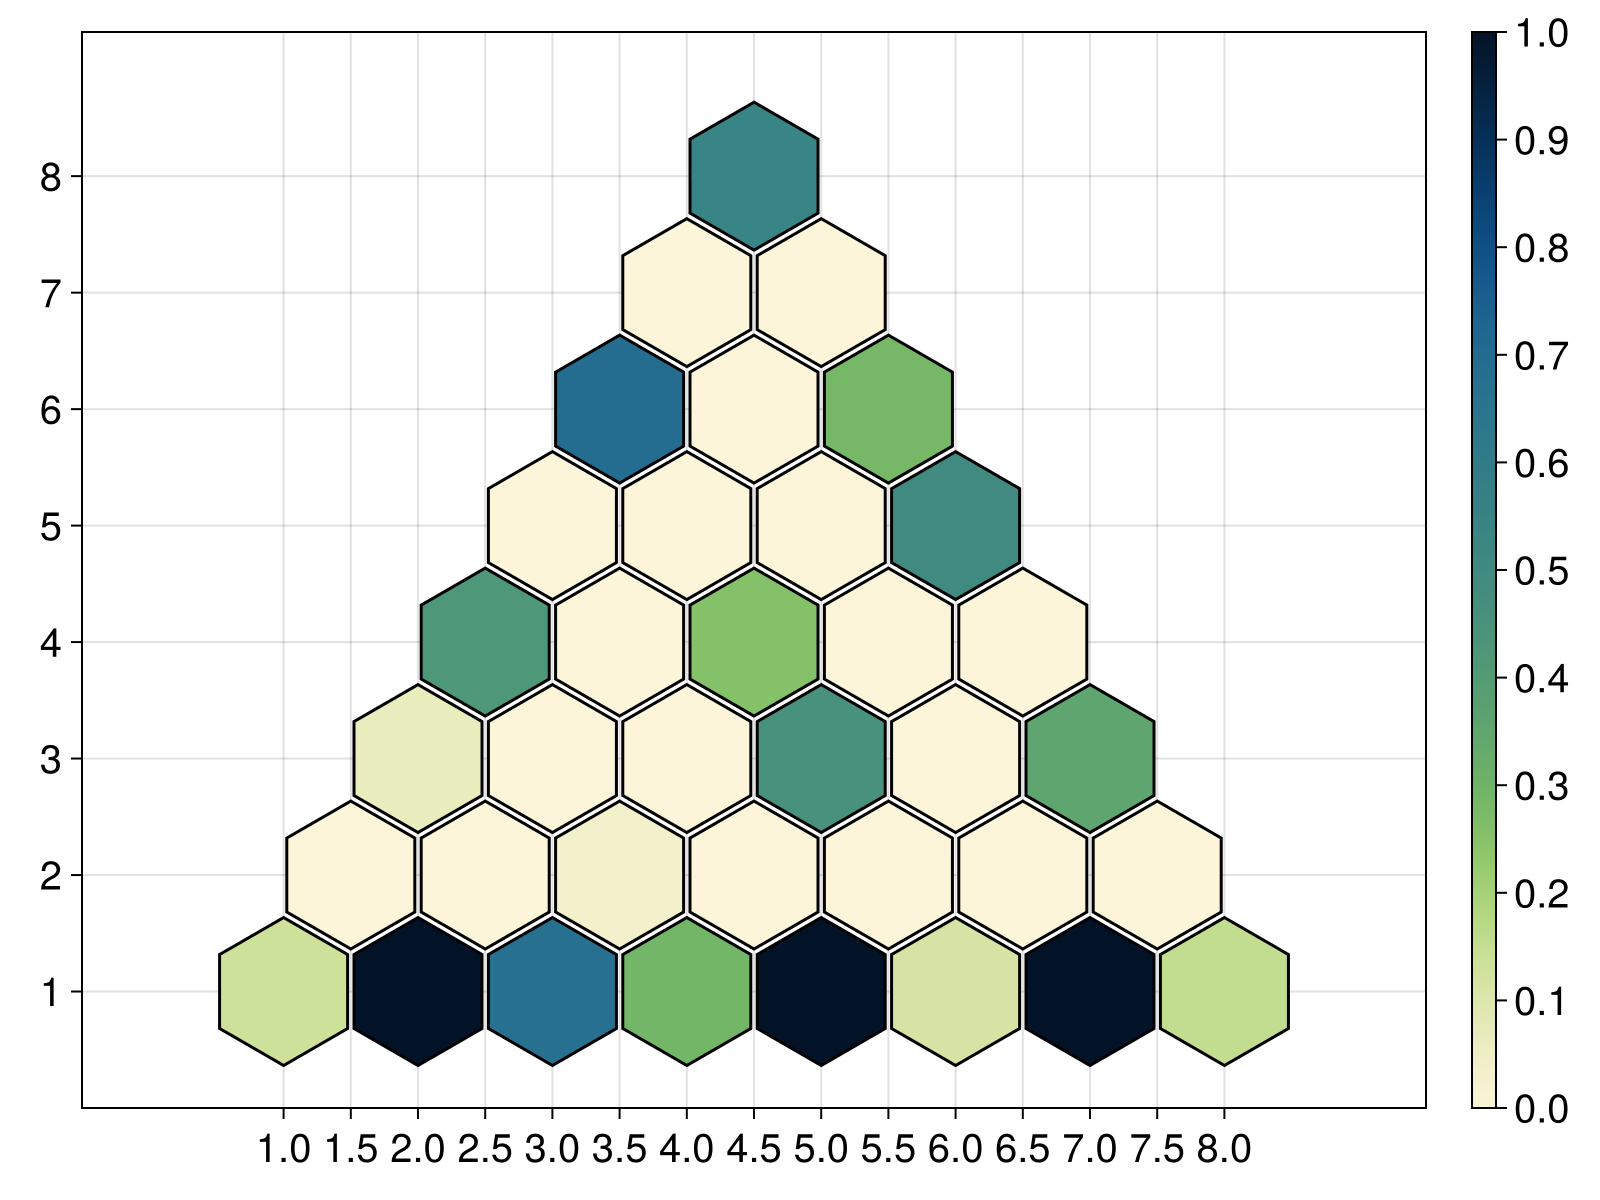

CairoMakie.Screen{IMAGE}


In [2]:
## CKT

L=8
epsilon=0.85
theta=0.0

U=brickwall(L,theta, epsilon)

eigvals,eigvecs=eigen(U);



info_lattice_t= Vector{Vector{Float64}}(undef, L)

 Psi=eigvecs[1,:]
 Psi=projectatt(Psi,[2 5 7])

info_lattice_t=info_lattice(Psi, L)



 fig=draw_info_lattice(info_lattice_t)
 display(fig)